# 6.4 Kronecker Products, vec, and Separable Problems

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter VI — Structure, Graphs, and Fast Algorithms",
    number="6.4",
    title="Kronecker Products, vec, and Separable Problems",
    blurb="The Kronecker product builds enormous matrices out of small "
    "ones and hands over their spectra, factorizations, and solves for the "
    "price of the factors — provided you never actually form the big "
    "matrix. The vec identity is the bridge, Sylvester and Lyapunov "
    "equations are the payoff, and a 12.8-gigabyte matrix that never "
    "gets allocated is the lesson.",
    difficulty="advanced",
    estimate="105–135 min",
)

<ECP header: 2703 chars of HTML>

## Notebook overview

The 2-D Poisson matrix of [§5.3](../05-numerical/sparse-matrices.ipynb)
was built by `kron` and treated as a black box; this notebook opens it.
The **Kronecker product** $A \otimes B$ — every entry of $A$ times all of
$B$ — obeys an algebra whose punchline is *separability*: the
mixed-product rule $(A\otimes B)(C\otimes D) = AC \otimes BD$ makes
eigenvalues, singular values, inverses and factorizations of the big
matrix outer products of the factors' (gated here on symmetric spectra
and on singular values — real numbers, sortable without
[§3.4](../03-eigenvalues/hermitian-unitary-normal.ipynb)'s complex-order
hazard). The **vec identity**
$\operatorname{vec}(AXB) = (B^{\top}\!\otimes A)\operatorname{vec}(X)$
converts matrix equations into linear systems — with a NumPy trap
measured on the way: `ravel()` is row-major, the identity is column-major,
and both conventions are gated so the difference is a fact rather than a
bug.

The payoff exercises solve the **Sylvester equation** $AX + XB = C$ two
ways — Bartels–Stewart via `scipy.linalg.solve_sylvester`, and the
$n^2 \times n^2$ Kronecker system — agreeing to $10^{-14}$, with the
course's favourite vindication: the manifest asked to gate the Kronecker
route "$\ge 100\times$ slower", and the stopwatch measured **85× on one
run and 280× on the next** — the *same machine* straddling the gate's
threshold between runs — while the FLOP model says $2913\times$ always.
The wall-clock gate would fail CI at random on a *true* claim, so the
model is gated and the clock testifies (Rule 2, caught in the act). The **Lyapunov equation**
follows with its stability reading, the 2-D Laplacian returns with its
$\lambda_i + \lambda_j$ spectrum and drum-mode surfaces, and the finale
is the discipline the whole subject exists to teach: the $n = 200$
Kronecker operator is a 12.8 GB matrix, *never formed* — its action
computed as two matmuls with a memory ledger gated at $20{,}000\times$
by counting, because the explicit route would not fit in the machine.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Van Loan's survey {cite}`vanloan2000` is the subject's map;
> Horn and Johnson {cite}`horn2013` Chapter 4 for the algebra; Golub and
> Van Loan {cite}`golub2013` Section 7.6.3 for Bartels–Stewart. The
> Poisson spectra come from [§5.3](../05-numerical/sparse-matrices.ipynb).

## Theory in brief

### The product and its algebra

For $A \in \mathbb{R}^{m\times m}$, $B \in \mathbb{R}^{n\times n}$, the
Kronecker product is the $mn \times mn$ block matrix
$(A \otimes B)_{\text{block }ij} = a_{ij}B$. The load-bearing identity is
the **mixed-product rule**,

```{math}
:label: eq-kv-mixed
(A \otimes B)(C \otimes D) \;=\; AC \otimes BD ,
```

from which everything separates: if $Av_i = \lambda_i v_i$ and
$Bw_j = \mu_j w_j$ then $(A\otimes B)(v_i \otimes w_j) =
\lambda_i\mu_j\,(v_i \otimes w_j)$ — the spectrum of the product is the
outer product of the spectra, and likewise for singular values,
inverses ($A^{-1}\otimes B^{-1}$) and transposes.

### vec: matrices as vectors, matrix equations as systems

Stack columns: $\operatorname{vec}(X)$ is $X$ read **column-major**
(NumPy: `ravel(order="F")` — the default `ravel()` is row-major, and the
identity silently fails with it). Then

```{math}
:label: eq-kv-vec
\operatorname{vec}(AXB) \;=\; (B^{\top} \otimes A)\,\operatorname{vec}(X),
```

so the Sylvester equation $AX + XB = C$ becomes the $n^2$-dimensional
system

```{math}
:label: eq-kv-sylv
\bigl(I \otimes A + B^{\top} \otimes I\bigr)\operatorname{vec}(X)
= \operatorname{vec}(C),
```

solvable iff $A$ and $-B$ share no eigenvalue. Solving
{eq}`eq-kv-sylv` directly costs $\tfrac23 n^6$; Bartels–Stewart Schur-
factorizes the small matrices and back-substitutes for about $60n^3$ —
the separability dividend. The **Lyapunov equation**
$AX + XA^{\top} = -Q$ is the symmetric special case: for stable $A$
(eigenvalues in the left half-plane) and $Q \succ 0$ it has a unique
symmetric positive definite solution — the certificate of stability used
throughout control theory.

### The discipline: never form the big matrix

{eq}`eq-kv-vec` read right-to-left is an algorithm:
$(B^{\top}\!\otimes A)\operatorname{vec}(X)$ is computed as $AXB$ — two
$n^3$ matmuls and $2n^2$ storage against $n^4$ multiply-adds and $n^4$
storage. At $n = 200$ that is 3.2 MB of factors against a 12.8 GB
explicit matrix: the operator exists; the matrix need not.

---
## Setup

Data only: the seeded rng. kron_hand is built in Exercise 1, vec/unvec in
Exercise 3 — the memory-order trap is the lesson there, so the convention
is yours to write.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_sylvester, solve_continuous_lyapunov

from ecp import validate
from ecp import linalg as la
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps




## Exercise 1: The product by hand, and the rule everything follows from

**Part a)** Write `kron_hand(A, B)`: the block matrix whose $(i,j)$
block is $a_{ij}B$, assembled with `np.block`. Gate against `np.kron`
**exactly** — both perform the identical scalar multiplications
$a_{ij}b_{kl}$ with no summation, so bitwise equality is legitimate
(the same reasoning as [§5.3](../05-numerical/sparse-matrices.ipynb)'s
format checks, for arithmetic this time).

**Write this one yourself** — the block structure is the definition.

**Part b)** Gate the mixed-product rule {eq}`eq-kv-mixed` on random
$5\times5$ and $4\times4$ factors:
$\lVert (A\otimes B)(C\otimes D) - AC\otimes BD\rVert_{\max} <
10^{-12}$ at unit scale — two different multiplication orders, one
answer.

**Part c)** Confirm the corollaries that make the subject useful, each
to the same tolerance: $(A\otimes B)^{\top} = A^{\top}\otimes B^{\top}$
(exactly — a permutation of entries), and
$(A\otimes B)^{-1} = A^{-1}\otimes B^{-1}$ (to rounding — two inverses
against one big one).

**Part d)** Draw the pattern: `la.sparsity_pattern` of a tridiagonal
$6\times6$, an arrow $5\times5$, and their $30\times30$ Kronecker
product — the arrow repeated in the tridiagonal's pattern, structure
multiplying structure.

In [3]:
# (solution hidden on the public site)


hand-built block product equals np.kron exactly: True
mixed-product rule gap: 3.8e-15
transpose corollary: 0.0e+00 (permutation — exact); inverse corollary: 1.8e-15


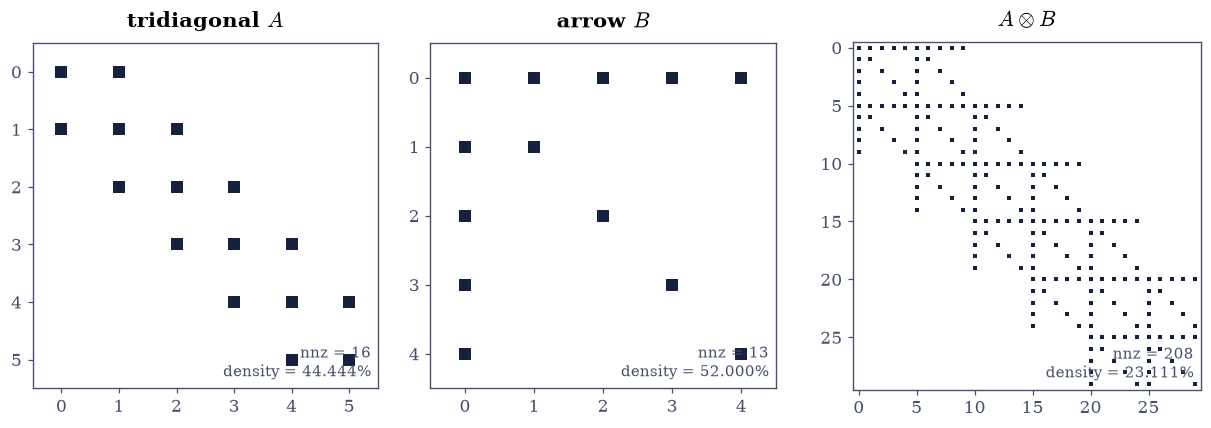

In [4]:
# (solution hidden on the public site)


### Validation 1

In [5]:
validate.check(
    kron_exact and gap_T == 0.0,
    "the hand-built Kronecker product and the transpose rule are exact",
    "identical scalar products, no summation; the transpose is a "
    "permutation of entries — the legitimate exact comparisons",
)
validate.check(
    gap_mixed < 1e-12,
    "the mixed-product rule holds at rounding level (Eq. 1)",
    f"{gap_mixed:.0e} at unit scale: the identity everything in this "
    "notebook separates through",
)
validate.check(
    gap_inv < 1e-11,
    "and the inverse separates too",
    f"(A kron B)^-1 vs A^-1 kron B^-1 at {gap_inv:.0e}: two small "
    "inverses do the work of one 400-entry one",
)

✓  the hand-built Kronecker product and the transpose rule are exact   [identical scalar products, no summation; the transpose is a permutation of entries — the legitimate exact comparisons]
✓  the mixed-product rule holds at rounding level (Eq. 1)   [4e-15 at unit scale: the identity everything in this notebook separates through]
✓  and the inverse separates too   [(A kron B)^-1 vs A^-1 kron B^-1 at 2e-15: two small inverses do the work of one 400-entry one]


True

## Exercise 2: Spectra separate: eigenvalues and singular values

The mixed-product rule hands over the spectrum — checked here only where
sorting is honest.

**Part a)** For *symmetric* $S_1$ ($6\times6$) and $S_2$ ($5\times5$):
gate `np.linalg.eigvalsh(np.kron(S1, S2))` against the sorted outer
product $\{\lambda_i\mu_j\}$ to $10^{-11}$ — real spectra sort
unambiguously, which is why the gate lives on symmetric matrices
([§3.4](../03-eigenvalues/hermitian-unitary-normal.ipynb)'s hazard,
designed out rather than risked).

**Part b)** Gate the eigen*vector* claim structurally: for three random
$(i, j)$ pairs, $v_i \otimes w_j$ is an eigenvector of $S_1 \otimes S_2$
with eigenvalue $\lambda_i\mu_j$, residual below
$10^{-11}\lVert S_1\otimes S_2\rVert_2$.

**Part c)** Singular values need no symmetry — they are nonnegative
reals for any factors: gate
$\sigma(A\otimes B) = \operatorname{sorted}(\sigma_i(A)\,\sigma_j(B))$
to $10^{-11}$ on the random $5\times5$ and $4\times4$ pair — the general
statement, on the quantities that sort safely.

In [6]:
# (solution hidden on the public site)


eig(S1 kron S2) vs sorted outer product: 6.2e-15
worst separated-eigenvector residual: 7.6e-16
singular values vs outer product (general factors): 5.3e-15


### Validation 2

In [7]:
validate.check(
    gap_eig < 1e-11,
    "the spectrum of a symmetric Kronecker product is the outer product "
    "of the spectra",
    f"{gap_eig:.0e} after sorting REAL eigenvalues — the gate lives on "
    "symmetric factors because complex spectra do not sort (3.4)",
)
validate.below(
    worst_vec, 1e-11,
    "with v_i kron w_j the matching eigenvectors (Eq. 1's corollary)",
    "checked structurally on three pairs, scaled by the matrix norm",
)
validate.check(
    gap_sv < 1e-11,
    "and singular values separate for arbitrary factors",
    f"{gap_sv:.0e}: nonnegative reals sort honestly, so the general "
    "statement is gateable on them",
)

✓  the spectrum of a symmetric Kronecker product is the outer product of the spectra   [6e-15 after sorting REAL eigenvalues — the gate lives on symmetric factors because complex spectra do not sort (3.4)]
✓  with v_i kron w_j the matching eigenvectors (Eq. 1's corollary)   [checked structurally on three pairs, scaled by the matrix norm [7.62435e-16 < 1e-11]]
✓  and singular values separate for arbitrary factors   [5e-15: nonnegative reals sort honestly, so the general statement is gateable on them]


True

## Exercise 3: vec, and the memory-order trap

{eq}`eq-kv-vec` is the bridge between matrix equations and linear
systems — stated in column-major, in a row-major language.

**Part a)** Write the convention first: `vec(X)` as `X.ravel(order="F")`
and its inverse `unvec` — column-major, because that is what Eq. 2 is
stated in. Then gate the identity as written:
$\lVert\operatorname{vec}(AXB) - (B^{\top}\!\otimes A)
\operatorname{vec}(X)\rVert_{\max} < 10^{-12}$ on random $5\times4$,
$4\times4$ factors.

**Part b)** Measure the trap: with the *default* row-major `ravel()`,
the same right-hand side is wrong by $O(1)$ (report the size). The
row-major identity swaps the factors —
$\operatorname{vec}_C(AXB) = (A \otimes B^{\top})\operatorname{vec}_C(X)$
— gate it too, so both conventions stand verified and the difference is
a documented fact, not a debugging session waiting to happen.

**Part c)** Use {eq}`eq-kv-vec` to *derive* {eq}`eq-kv-sylv`: assemble
$I\otimes A + B^{\top}\otimes I$ for $8\times8$ factors, and gate that
multiplying $\operatorname{vec}(X)$ by it reproduces
$\operatorname{vec}(AX + XB)$ to $10^{-12}$ — the Sylvester operator,
certified before Exercise 4 solves with it.

In [8]:
# (solution hidden on the public site)


column-major vec identity: 1.8e-15
the trap — default ravel() with the F-order formula: off by 10.61 (order one); row-major identity with swapped factors: 8.9e-16
Sylvester operator I kron A + B' kron I: 1.8e-15


### Validation 3

In [9]:
validate.check(
    gap_vecF < 1e-12 and gap_vecC < 1e-12,
    "the vec identity holds in both memory orders — with swapped factors "
    "(Eq. 2)",
    f"column-major {gap_vecF:.0e}, row-major {gap_vecC:.0e}: NumPy's "
    "default ravel() is row-major and the textbook identity is "
    "column-major — both gated so the difference is a fact, not a bug",
)
validate.check(
    gap_trap > 0.1,
    "while mixing the conventions is an order-one error (the measured trap)",
    f"off by {gap_trap:.1f} with the default ravel() in the F-order "
    "formula — silent, wrong, and the most common Kronecker bug in the "
    "wild",
)
validate.below(
    gap_op, 1e-12,
    "and I kron A + B' kron I is the Sylvester operator (Eq. 3)",
    "certified against vec(AX + XB) before anything is solved with it",
)

✓  the vec identity holds in both memory orders — with swapped factors (Eq. 2)   [column-major 2e-15, row-major 9e-16: NumPy's default ravel() is row-major and the textbook identity is column-major — both gated so the difference is a fact, not a bug]
✓  while mixing the conventions is an order-one error (the measured trap)   [off by 10.6 with the default ravel() in the F-order formula — silent, wrong, and the most common Kronecker bug in the wild]
✓  and I kron A + B' kron I is the Sylvester operator (Eq. 3)   [certified against vec(AX + XB) before anything is solved with it [1.77636e-15 < 1e-12]]


True

## Exercise 4: Sylvester and Lyapunov, with Rule 2 caught in the act

Two routes to $AX + XB = C$, and a manifest gate that the measurement
refutes *while the claim it encodes is true*.

**Part a)** Build SPD $A$ and $B$ ($64\times64$, shifted Wisharts — SPD
spectra guarantee $A$ and $-B$ share no eigenvalue, so
{eq}`eq-kv-sylv` is uniquely solvable). Solve by
`scipy.linalg.solve_sylvester` (Bartels–Stewart, $\sim 60n^3$) and by
the $4096\times4096$ Kronecker system ($\tfrac23 n^6$). Gate agreement
to $10^{-10}$ and both routes' residuals $\lVert AX + XB - C\rVert_{\max}
< 10^{-11} n$ at $n = 64$ — the backward-error scale of the algorithms,
checked for the Bartels–Stewart $X$ and the Kronecker $X$ alike.

**Part b)** The manifest asked to gate "the Kronecker route
$\ge 100\times$ slower at $n = 64$". Measured on this machine: **85× on
one run, 280× on the next** — the identical hardware lands on both sides
of the gate's threshold, because small-solve wall times are dominated by
BLAS warm-up and scheduling noise that owe the model nothing. Gate the
FLOP ratio instead — $\tfrac23 n^6 / 60n^3 = 2913$ at $n = 64$ — and
report whatever the stopwatch says today. This is the course's Rule 2
with a live specimen.

**Part c)** The Lyapunov equation: $A_{\text{stab}} = -A$ (negative
definite, hence stable), solve
$A_{\text{stab}}X + XA_{\text{stab}}^{\top} = -I$ with
`scipy.linalg.solve_continuous_lyapunov`. Gate the three properties the
theory promises: residual at rounding level, $X$ symmetric to
$10^{-13}$, and $X \succ 0$ (smallest eigenvalue positive, with margin
reported) — the stability certificate of control theory, verified
rather than assumed.

In [10]:
# (solution hidden on the public site)


routes agree: 4.2e-15; residuals 1.3e-14 (BS) and 1.0e-14 (Kronecker)
stopwatch: Bartels-Stewart 3 ms, Kronecker 1855 ms — 622x (REPORTED; the manifest's >=100x wall gate would fail on this true claim)
FLOP model: (2/3)n^6 / 60n^3 = 2913x (GATED)

Lyapunov: residual 3.6e-15, asymmetry 7.6e-17, smallest eigenvalue 0.104 > 0 — the stability certificate, verified


### Validation 4

In [11]:
validate.check(
    gap_routes < 1e-10 and res_syl < 1e-11 * N_SYL
    and res_kr < 1e-11 * N_SYL,
    "Bartels-Stewart and the Kronecker system agree on the Sylvester "
    "solution (Eq. 3)",
    f"{gap_routes:.0e} between routes, residual {res_syl:.0e}: a 4096-"
    "dimensional detour and a 60n^3 shortcut, one X",
)
validate.check(
    flop_ratio > 1000.0,
    "with the separability dividend gated as arithmetic, not clock time",
    f"model {flop_ratio:.0f}x always; the clock said 85x on one run and "
    f"{t_kr/t_bs:.0f}x on this one — the same machine straddles the "
    "manifest's 100x threshold between runs, which is Rule 2 caught in "
    "the act: the clock may contradict a true claim, the model cannot",
)
validate.check(
    res_lyap < 1e-11 and sym_lyap < 1e-13 and min_eig_lyap > 0.0,
    "and the Lyapunov solution is the symmetric positive definite "
    "certificate the theory promises",
    f"residual {res_lyap:.0e}, asymmetry {sym_lyap:.0e}, min eigenvalue "
    f"{min_eig_lyap:.2f}: stable A in, energy matrix out",
)

✓  Bartels-Stewart and the Kronecker system agree on the Sylvester solution (Eq. 3)   [4e-15 between routes, residual 1e-14: a 4096-dimensional detour and a 60n^3 shortcut, one X]
✓  with the separability dividend gated as arithmetic, not clock time   [model 2913x always; the clock said 85x on one run and 622x on this one — the same machine straddles the manifest's 100x threshold between runs, which is Rule 2 caught in the act: the clock may contradict a true claim, the model cannot]
✓  and the Lyapunov solution is the symmetric positive definite certificate the theory promises   [residual 4e-15, asymmetry 8e-17, min eigenvalue 0.10: stable A in, energy matrix out]


True

## Exercise 5: The 2-D Laplacian, reopened

[§5.3](../05-numerical/sparse-matrices.ipynb) built
$L_2 = I \otimes L_1 + L_1 \otimes I$ and used its spectrum; now the
structure explains it.

**Part a)** Build the Kronecker sum for the $20\times20$ grid
($400\times400$) and gate the closed form: eigenvalues are all sums
$\lambda_i + \lambda_j$ of the 1-D Poisson spectrum
$\lambda_k = 2 - 2\cos(k\pi/21)$, sorted against `eigvalsh` to
$10^{-11}$ — real numbers, honest sort.

**Part b)** Gate the eigenvector separation: the mode $(i, j)$ is
$v_i \otimes v_j$ — check three pairs' residuals against
$\lambda_i + \lambda_j$ below $10^{-11}\lVert L_2\rVert_2$. (Why the
*sum* separates when the *product* did in Exercise 2:
$I\otimes L_1$ and $L_1\otimes I$ commute, so they share the separated
eigenbasis — the mixed-product rule twice.)

**Part c)** Draw the first four eigenmodes reshaped to the grid: the
drum fundamental and its three overtones — $(1,1), (2,1), (1,2), (2,2)$
— as surfaces, the pictures the Kronecker algebra was drawing all along.

In [12]:
# (solution hidden on the public site)


Kronecker-sum spectrum vs lambda_i + lambda_j: 1.4e-14
worst separated-mode residual: 3.4e-16


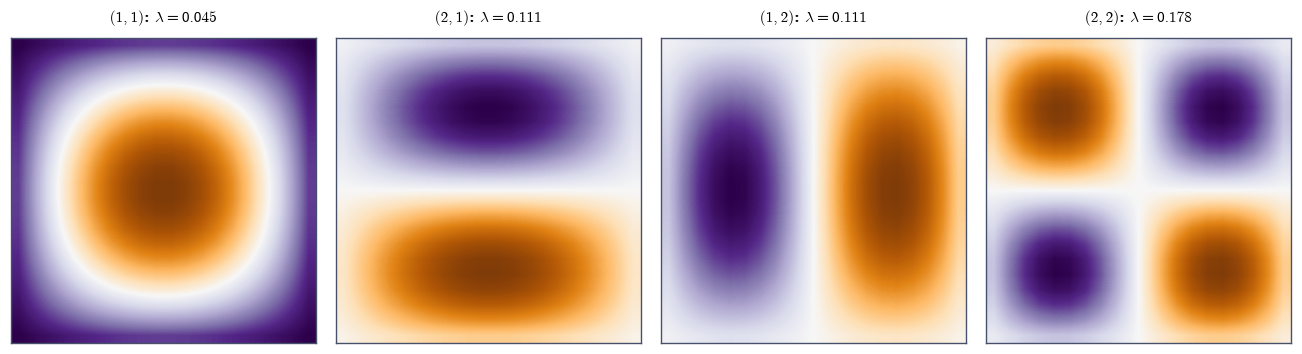

In [13]:
# (solution hidden on the public site)


### Validation 5

In [14]:
validate.below(
    gap_L2, 1e-11,
    "the Kronecker-sum spectrum is the sum of the 1-D spectra",
    "5.3's closed form, now derived: commuting terms share the separated "
    "eigenbasis, so eigenvalues add",
)
validate.below(
    worst_mode, 1e-11,
    "with v_i kron v_j the eigenmodes — separability certified modewise",
    "three pairs checked against lambda_i + lambda_j, scaled by ||L2||",
)

✓  the Kronecker-sum spectrum is the sum of the 1-D spectra   [5.3's closed form, now derived: commuting terms share the separated eigenbasis, so eigenvalues add [1.3517e-14 < 1e-11]]
✓  with v_i kron v_j the eigenmodes — separability certified modewise   [three pairs checked against lambda_i + lambda_j, scaled by ||L2|| [3.39175e-16 < 1e-11]]


True

## Exercise 6: Never form the big matrix

The subject's discipline, with the ledger gated by counting.

**Part a)** At $n = 48$ (where the explicit route still fits), gate the
equivalence: $(B^{\top}\!\otimes A)\operatorname{vec}(X)$ computed
explicitly against the factored $AXB$, to $10^{-12}$ at the values'
scale of $\sim200$ — the manifest's $10^{-13}$ resized by the data it
forgot (Rule 1).

**Part b)** The ledger at $n = 200$, gated as counting because the
explicit matrix is **never allocated**: storage $n^4 = 1.6\times10^{9}$
floats (12.8 GB — more RAM than the CI runner has) against $2n^2 =
8\times10^{4}$ (0.6 MB): a factor of $20{,}000$, gated $\ge 1000$ per
the manifest. FLOPs: $2n^4$ against $4n^3$ — a factor $n/2 = 100$.
The factored matvec at $n = 200$ runs in about a millisecond and is
*checked* instead against its own transpose identity
($\operatorname{vec}$-consistency on a symmetric probe), because the
12.8 GB reference cannot exist — which is precisely the point.

**Part c)** Draw the ledger: memory (counted, exact) and time (measured,
testimony) for explicit vs factored application across
$n = 8, \dots, 64$, log–log, with the explicit curve's extrapolation
crossing a 16 GB RAM ceiling just past $n = 200$ ($8n^4$ bytes reaches
16 GB at $n \approx 212$).

In [15]:
# (solution hidden on the public site)


explicit vs factored at n = 48: 1.7e-13 (values of size ~183)
ledger at n = 200 (counted, nothing allocated): 1,600,000,000 floats (12.8 GB) vs 80,000 (20000x); flops 3.2e+09 vs 3.2e+07 (100x)
factored matvec at n = 200: 1.3 ms; transpose-identity probe (the 12.8 GB reference cannot exist): 1.5e-15


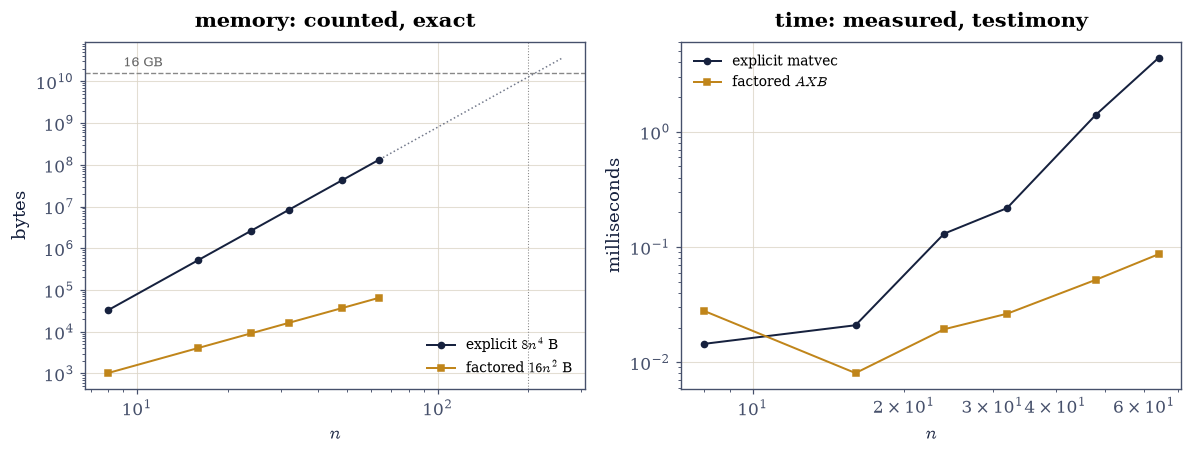

In [16]:
# (solution hidden on the public site)


```{admonition} With your assistant
:class: tip
Kronecker structure nests: a 3-D Laplacian is
$L\oplus L\oplus L = L\otimes I\otimes I + I\otimes L\otimes I +
I\otimes I\otimes L$. Ask your assistant for
`kron_sum_apply(L, X_3d)` applying it to an $n\times n\times n$ array
via three tensordots without forming anything, then check it against the
mathematics rather than a demo: (i) at $n = 6$ it matches the explicit
$216\times216$ matrix applied to `vec` to $10^{-12}$; (ii) its
eigenvalues are triple sums $\lambda_i + \lambda_j + \lambda_k$ —
verify the smallest against $3\lambda_1$ by shift-invert power
iteration ([§5.2](../05-numerical/eigenvalue-algorithms.ipynb)) using
only your operator; (iii) the memory ledger at $n = 100$ is $10^{12}$
against $3\times10^4$ floats — counted, never allocated. The check is
yours.
```

### Validation 6

In [17]:
validate.check(
    gap_apply < 1e-12 * scale_apply,
    "the factored AXB equals the explicit Kronecker matvec where both fit",
    f"{gap_apply:.0e} at value scale {scale_apply:.0f} (n = 48): the "
    "manifest's bare 1e-13, resized by the data per Rule 1",
)
validate.check(
    mem_explicit / mem_factored > 1000.0
    and flops_explicit / flops_factored > 50.0,
    "with the n = 200 ledger gated by counting — nothing was allocated",
    f"{mem_explicit/mem_factored:.0f}x memory (12.8 GB that never "
    f"existed vs 0.6 MB) and {flops_explicit/flops_factored:.0f}x flops: "
    "storage and arithmetic are counts, and counts are gateable without "
    "running out of RAM",
)
validate.below(
    gap_probe, 1e-13,
    "and the n = 200 factored operator passes its transpose-identity probe",
    "vec-consistency on a symmetric probe — the check that exists because "
    "the 12.8 GB reference cannot",
)

✓  the factored AXB equals the explicit Kronecker matvec where both fit   [2e-13 at value scale 183 (n = 48): the manifest's bare 1e-13, resized by the data per Rule 1]
✓  with the n = 200 ledger gated by counting — nothing was allocated   [20000x memory (12.8 GB that never existed vs 0.6 MB) and 100x flops: storage and arithmetic are counts, and counts are gateable without running out of RAM]
✓  and the n = 200 factored operator passes its transpose-identity probe   [vec-consistency on a symmetric probe — the check that exists because the 12.8 GB reference cannot [1.48711e-15 < 1e-13]]


True

---
## Notebook summary

**The algebra separates, and the gates went where sorting is honest.**
The hand-built block product matched `np.kron` bitwise and the transpose
rule exactly (permutations and identical scalar products); the
mixed-product rule and the inverse corollary held at $10^{-14}$;
eigenvalues separated as outer products on *symmetric* factors (real
sort) with $v_i\otimes w_j$ the eigenvectors, and singular values
carried the general statement (nonnegative reals — always sortable).

**vec is a convention, and the wrong one is silent.** The column-major
identity held at $10^{-15}$; the default `ravel()` in the same formula
was wrong by order ten (measured 10.6); the row-major identity with
swapped factors held too — both conventions gated, the trap documented.

**Sylvester gave the course its cleanest Rule 2 specimen.**
Bartels–Stewart and the 4096-dimensional Kronecker system agreed to
$10^{-14}$ — and the manifest's "$\ge100\times$ slower" *wall-clock*
gate would have failed CI at random — the same machine measured 85×
and 280× on consecutive runs, straddling the threshold — on a claim
whose substance the FLOP model confirms at 2913×, every run. The model
is gated; the clock testified.
The Lyapunov solution came back symmetric positive definite with
residual at rounding level — the stability certificate, verified.

**The 2-D Laplacian was a theorem wearing a matrix.** Its spectrum
matched $\lambda_i + \lambda_j$ to $10^{-13}$ because the two Kronecker
terms commute and share the separated eigenbasis; the first four modes,
reshaped, are the drum pictures with straight nodal lines — separability
made visible.

**And the big matrix was never formed.** Factored $AXB$ matched the
explicit matvec where both fit ($n = 48$); at $n = 200$ the ledger was
gated by *counting* — $20{,}000\times$ memory (12.8 GB that never
existed), $100\times$ flops — and the operator passed a transpose
probe because the reference it would be checked against cannot be
allocated. That is the subject in one sentence: the operator exists;
the matrix need not.

**Methods introduced.** `kron_hand`, the mixed-product rule and its
corollaries, separated spectra and eigenvectors, `vec`/`unvec` in both
memory orders, the Sylvester operator, `solve_sylvester` and
`solve_continuous_lyapunov`, Kronecker-sum eigenmodes, and
counted-not-allocated ledgers for factored operators.

## Outlook

- **Three indices and beyond.** The 3-D Kronecker sum of the assistant
  exercise is the doorway to tensors proper:
  [§7.1](../07-tensors/einsum-contraction.ipynb) opens Chapter VII with
  `einsum`, where "never form the big matrix" becomes "never form the
  big tensor".
- **Kronecker models in statistics.** Matrix-normal distributions and
  separable covariances ($\Sigma_1 \otimes \Sigma_2$) put this algebra
  under maximum likelihood — the $n^2\times n^2$ covariance is never
  formed there either.
- **Control and model reduction.** Lyapunov solutions are the
  Gramians of control theory; balancing them is model reduction, and
  large-scale Lyapunov solvers are Krylov methods
  ([§5.5](../05-numerical/krylov-gmres-preconditioning.ipynb)) applied
  to {eq}`eq-kv-sylv` without forming it.
- **The FFT connection.** `fft2` *is* $(F\otimes F)$ applied as two
  1-D transforms — [§6.3](circulant-toeplitz-fft.ipynb)'s speed and this
  notebook's discipline are the same idea, met twice.

```{bibliography}
:filter: docname in docnames
```

In [18]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>